#### Import Libraries

In [1]:
import duckdb
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', lambda x: '%.2f' % x)

con = duckdb.connect('/app/data/analytics.duckdb')

#### Load Dataset (only Delivered Orders)

In [2]:
df = con.sql("SELECT * FROM mart.mart_order_items WHERE is_delivered = TRUE").df()
df.head()

,order_id,order_item_id,order_item_key,product_id,seller_id,shipping_limit_date_et,price,freight_value,total_item_value,freight_pct_of_price,customer_unique_id,order_status,is_delivered,is_in_progress,is_canceled,order_purchase_timestamp_et,order_delivered_customer_date_et,order_estimated_delivery_date_et,is_delivered_on_time,days_to_delivery,delivery_speed_category,customer_city,customer_state,customer_state_name,customer_region,review_score,review_sentiment,has_review,days_to_review,is_quick_review,is_payment_details_missing,total_payment_value,total_payment_installments,first_payment_type,primary_payment_type,primary_payment_category,revenue_delivered,product_price_delivered,freight_delivered,product_name_length,product_description_length,product_category_name,product_category_name_english,broad_category,product_weight_g,product_length_cm,product_height_cm,product_width_cm,product_volume_cm3,volumetric_weight_kg,chargeable_weight_kg,freight_per_kg,product_size_category,is_heavy_item,is_high_value_item,has_photos,has_detailed_description,seller_city,seller_state,seller_zip_code_prefix,seller_geolocation_latitude,seller_geolocation_longitude,seller_state_name,seller_region,customer_zip_code_prefix,customer_geolocation_latitude,customer_geolocation_longitude,customer_total_orders,customer_total_delivered_orders,customer_in_progress_orders,customer_canceled_orders,customer_cancellation_rate,customer_has_repeat_orders,customer_lifetime_value,customer_first_order_date,customer_last_order_date,customer_lifetime_days,customer_avg_days_between_orders,customer_pct_orders_paid_with_voucher,customer_pct_orders_paid_with_credit_card,customer_dominant_payment_type,customer_avg_review_score,customer_reviewed_orders,customer_review_rate,seller_total_orders,seller_total_delivered_orders,seller_has_repeat_orders,seller_in_progress_orders,seller_canceled_orders,seller_cancellation_rate,seller_total_items_sold,seller_unique_products_sold,seller_unique_categories_sold,seller_avg_item_price,seller_avg_freight_per_item,seller_total_product_revenue,seller_total_freight_collected,seller_total_order_value,seller_lifetime_value,seller_avg_delivery_days,seller_on_time_delivery_rate,seller_avg_review_score,seller_reviewed_orders,seller_positive_review_rate,seller_first_sale_date,seller_last_sale_date,seller_tenure_days,product_broad_category,product_total_orders,product_total_units_sold,product_total_revenue,product_total_freight,product_total_value,product_avg_price,product_avg_freight,product_avg_review_score,product_reviewed_orders,product_positive_review_rate,product_avg_delivery_days,product_unique_sellers,product_first_sale_date,product_last_sale_date,cluster_name
0,000e562887b1f2006d75e0be9558292e,1,fd988f3296faed58cadf12b4abbe8aff,5ed9eaf534f6936b51d0b6c5e4d5c2e9,8cbac7e12637ed9cffa18c7875207478,2018-02-28 10:08:37,25.00,16.11,41.11,0.64,b2c72d1e9f6430603b8337d8f1394a99,delivered,True,False,False,2018-02-22 09:54:42,2018-03-12 17:46:34,2018-03-18 23:00:00,True,18,slow,cubatao,SP,São Paulo,Southeast,3,neutral,True,0,True,False,41.11,4.00,credit_card,credit_card,card,41.11,25.00,16.11,51,693,cool_stuff,cool_stuff,"Sports, Leisure & Toys",600,20,20,21,8400,1.40,1.40,11.51,medium,False,False,True,True,jaragua do sul,SC,89254,-26.47,-49.11,Santa Catarina,South,11533,-23.93,-46.41,1,1,0,0,0.00,False,41.11,2018-02-22 09:54:42,2018-02-22 09:54:42,0,NaN,0.00,1.00,credit_card,3.00,1,1.00,67,66,True,1,0,0.00,81,21,4,36.49,20.26,2955.98,1640.73,4596.71,7204.30,13.44,1.17,4.15,82,0.72,2017-01-26 11:29:25,2018-08-27 17:25:28,578,"Sports, Leisure & Toys",19,21,524.64,393.55,918.19,24.98,18.74,3.48,21,0.48,15.10,1,2017-06-07 15:26:44,2018-08-27 17:25:28,Top Performers
1,00137e170939bba5a3134e2386413108,1,9c7db80fcf5c685fd76ceef20b91ab90,672e757f331900b9deea127a2a7b79fd,e59aa562b9f8076dd550fcddf0e73491,2017-11-30 03:30:55,397.00,24.65,421.65,0.06,38c3bc2d6df03905e3e8d3d5b079acf4,delivered,True,False,False,2017-11-24 13:50:38,2017-12-11 16:12:55,2017-12-17 21:00

#### Seller level Information

In [3]:
sellers = df.groupby('seller_id').agg(
    total_orders=('order_id', 'nunique'),
    total_items=('order_item_id', 'count'),
    total_revenue=('revenue_delivered', 'sum'),
    avg_price=('price', 'mean'),
    unique_products=('product_id', 'nunique'),
    unique_categories=('broad_category', 'nunique'),
    seller_region=('seller_region', 'first'),
    seller_state=('seller_state', 'first')
).reset_index()

# Order-level features (deduplicated)
order_seller = df.drop_duplicates(subset=['order_id', 'seller_id'])
order_level = order_seller.groupby('seller_id').agg(
    avg_review_score=('review_score', 'mean'),
    avg_delivery_days=('days_to_delivery', 'mean'),
    on_time_rate=('is_delivered_on_time', 'mean')
).reset_index()

sellers = sellers.merge(order_level, on='seller_id', how='left')

In [4]:
# Dominant Category
dominant_cat = df.groupby('seller_id')['broad_category'].agg(
    lambda x: x.value_counts().index[0] if len(x.value_counts()) > 0 else 'Unknown').rename('dominant_category')
 
# Category concentration (% of items from top category)
def top_cat_pct(x):
    vc = x.value_counts(normalize=True)
    return vc.iloc[0] if len(vc) > 0 else 0

cat_concentration = df.groupby('seller_id')['broad_category'].agg(top_cat_pct).rename('category_concentration')

In [5]:
sellers = sellers.merge(dominant_cat, on='seller_id', how='left')
sellers = sellers.merge(cat_concentration, on='seller_id', how='left')

print(f"Total sellers: {len(sellers)}")
sellers.head()

Total sellers: 2970


,seller_id,total_orders,total_items,total_revenue,avg_price,unique_products,unique_categories,seller_region,seller_state,avg_review_score,avg_delivery_days,on_time_rate,dominant_category,category_concentration
0,0015a82c2db000af6aaaf3ae2ecb0532,3,3,2748.06,895.00,1,1,Southeast,SP,3.67,10.67,1.00,Other / Misc,1.00
1,001cca7ae9ae17fb1caed9dfb1094831,195,234,33142.90,104.65,11,2,Southeast,ES,4.06,13.42,0.93,Home & Living,0.88
2,002100f778ceb8431b7a1020ff7ab48f,50,54,1995.16,22.53,24,1,Southeast,SP,3.96,16.20,0.82,Home & Living,1.00
3,003554e2dce176b5555353e4f3555ac8,1,1,139.38,120.00,1,0,Central-West,GO,5.00,4.00,1.00,Unknown,0.00
4,004c9cd9d87a3c30c522c48c4fc07416,156,168,23094.02,116.49,87,1,Southeast,SP,4.17,14.80,0.92,Home & Living,1.00


#### Feature Selection

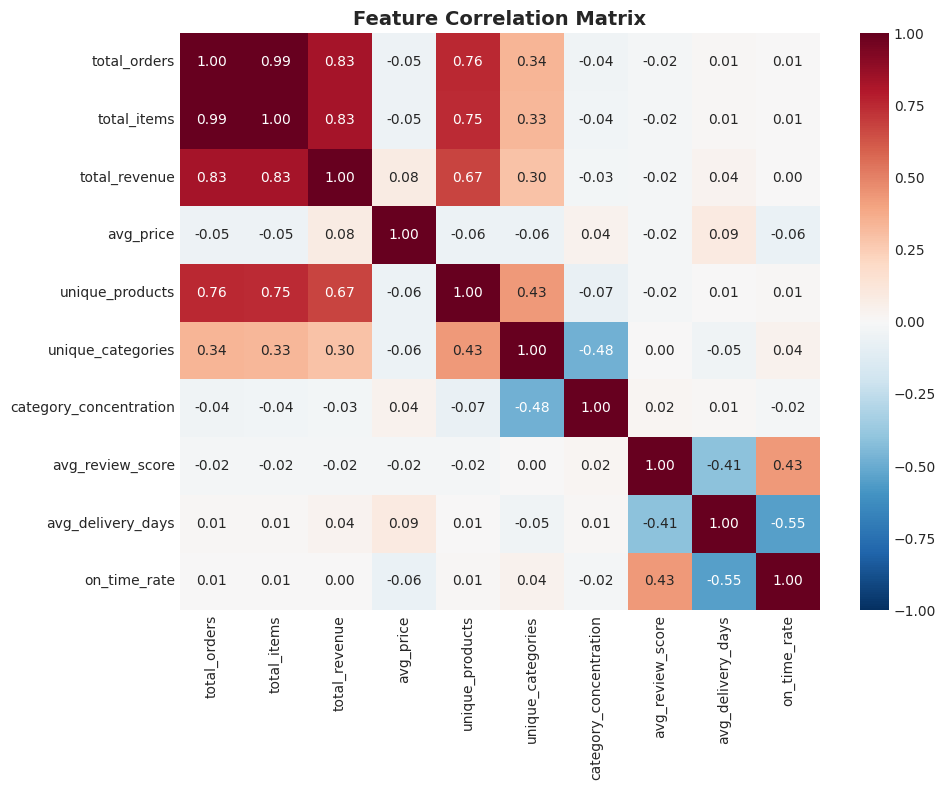

In [6]:
# Correlation matrix of clustering features
all_cols = ['total_orders', 'total_items', 'total_revenue', 
            'avg_price', 'unique_products', 'unique_categories', 'category_concentration', 
            'avg_review_score', 'avg_delivery_days', 'on_time_rate']
corr = sellers[all_cols].corr()

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdBu_r', center=0, ax=ax,
            vmin=-1, vmax=1)
ax.set_title('Feature Correlation Matrix', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig('/app/outputs/07_correlation_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

**Observations -**  
The correlation matrix reveals high redundancy: `total_orders` and `total_items` are nearly identical (0.99), 
and `unique_categories` inversely mirrors `category_concentration` (-0.48) while also correlating with `total_orders` (0.34). 
We drop `total_items` and `unique_categories` to reduce redundancy.

The remaining 8 features capture three distinct dimensions:
- volume (total_orders, total_revenue), 
- business type (avg_price, unique_products, category_concentration), and
- quality (avg_review_score, avg_delivery_days, on_time_rate).

#### Feature Columns

In [7]:
feature_cols = ['total_orders', 'total_revenue', 
                'avg_price', 'unique_products', 'category_concentration', 
                'avg_review_score', 'avg_delivery_days', 'on_time_rate']
sellers[feature_cols].describe()

,total_orders,total_revenue,avg_price,unique_products,category_concentration,avg_review_score,avg_delivery_days,on_time_rate
count,2970.00,2970.00,2970.00,2970.00,2970.00,2965.00,2970.00,2970.00
mean,32.93,5191.38,177.64,11.33,0.88,4.18,12.14,0.92
std,105.41,15938.53,345.12,24.53,0.21,0.78,7.16,0.17
min,1.00,15.22,6.00,1.00,0.00,1.00,1.00,0.00
25%,2.00,281.03,52.31,2.00,0.82,3.97,8.29,0.90
50%,7.00,1038.62,95.54,4.00,1.00,4.29,11.00,1.00
75%,22.00,4158.54,171.73,10.00,1.00,4.67,14.00,1.00
max,1819.00,247007.06,6735.00,394.00,1.00,5.00,190.00,1.00


#### Handle Missing Values

In [8]:
print(f"\nMissing values:")
print(sellers[feature_cols].isnull().sum())


Missing values:
total_orders              0
total_revenue             0
avg_price                 0
unique_products           0
category_concentration    0
avg_review_score          5
avg_delivery_days         0
on_time_rate              0
dtype: int64


In [9]:
sellers['avg_review_score'] = sellers['avg_review_score'].fillna(sellers['avg_review_score'].median())

#### Scaling
K-Means uses Euclidean distance, so features on different scales (e.g., `revenue` up to R$247K vs `on_time_rate` 0-1) would skew results.  
StandardScaler normalizes all features to mean=0, std=1 so they contribute equally.

In [10]:
X = sellers[feature_cols].copy()

# Scale
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print(f"Shape: {X_scaled.shape}")

Shape: (2970, 8)


### Clustering

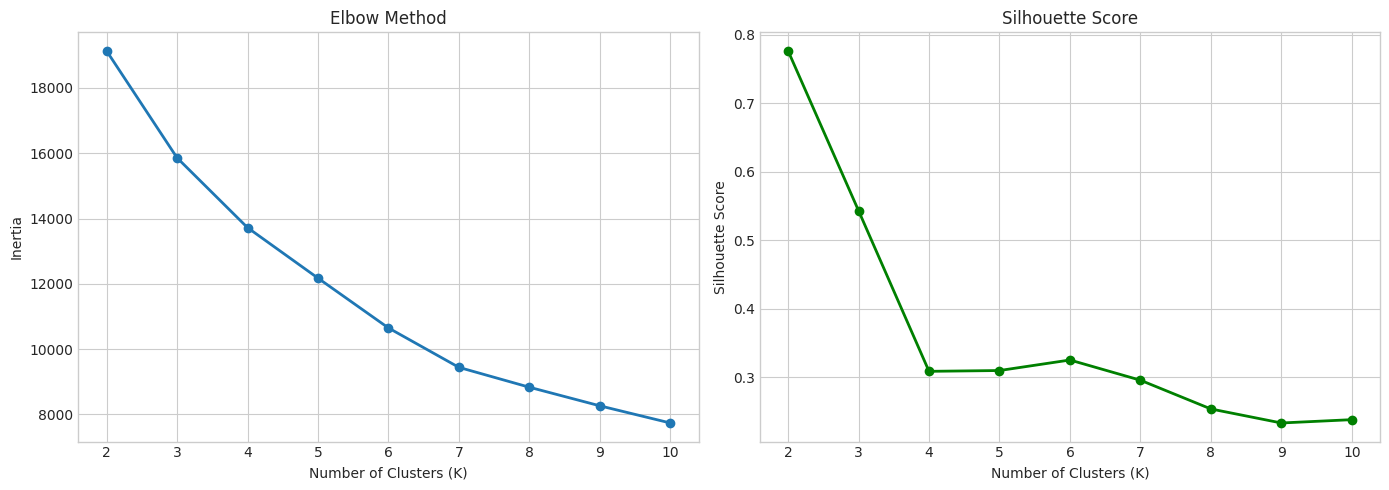

K=2: Silhouette = 0.777
K=3: Silhouette = 0.543
K=4: Silhouette = 0.309
K=5: Silhouette = 0.310
K=6: Silhouette = 0.325
K=7: Silhouette = 0.296
K=8: Silhouette = 0.254
K=9: Silhouette = 0.233
K=10: Silhouette = 0.238


In [11]:
inertias = []
silhouettes = []
K_range = range(2, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_scaled)
    inertias.append(kmeans.inertia_)
    silhouettes.append(silhouette_score(X_scaled, labels))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(K_range, inertias, marker='o', linewidth=2)
axes[0].set_title('Elbow Method')
axes[0].set_xlabel('Number of Clusters (K)')
axes[0].set_ylabel('Inertia')

axes[1].plot(K_range, silhouettes, marker='o', linewidth=2, color='green')
axes[1].set_title('Silhouette Score')
axes[1].set_xlabel('Number of Clusters (K)')
axes[1].set_ylabel('Silhouette Score')

plt.tight_layout()
plt.savefig('/app/outputs/08_optimal_k_without_log.png', dpi=150, bbox_inches='tight')
plt.show()

for k, s in zip(K_range, silhouettes):
    print(f"K={k}: Silhouette = {s:.3f}")

**Choosing K**  
The elbow method shows a clear bend at K=3. Silhouette scores confirm this: K=2 (0.777) only separates 
high-volume from low-volume sellers, while K=3 (0.543) is significantly stronger than K=4+ (0.309). 
We proceed with K=3 for the initial clustering.

In [12]:
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
sellers['cluster'] = kmeans.fit_predict(X_scaled)

# Cluster profiles
profile = sellers.groupby('cluster')[feature_cols].mean()
profile['count'] = sellers.groupby('cluster').size()
profile

,total_orders,total_revenue,avg_price,unique_products,category_concentration,avg_review_score,avg_delivery_days,on_time_rate,count
cluster,,,,,,,,,
0,5.10,2247.74,439.89,3.05,0.91,2.91,27.12,0.44,196
1,786.21,115146.28,137.53,158.03,0.84,4.10,13.16,0.92,34
2,25.58,4037.54,159.38,10.10,0.88,4.27,11.06,0.95,2740


**Observations -**  
Cluster 2 contains 2,740 sellers (92%) while Cluster 1 has only 34 power sellers. 
The extreme skewness in volume features causes K-Means to isolate the top sellers and 
lump the vast majority together. Cluster 0 (196 sellers) captures underperformers with 
low review scores (2.91), slow delivery (27 days), and poor on-time rates (44%). 
The clusters identify extremes well but lack nuance in the large middle group.

#### Log Transformations

In [13]:
# Log transform skewed features
X_log = sellers[feature_cols].copy()
log_cols = ['total_orders', 'total_revenue', 'avg_price', 'unique_products']
for col in log_cols:
    X_log[col] = np.log1p(X_log[col])

# Scale
X_log_scaled = scaler.fit_transform(X_log)

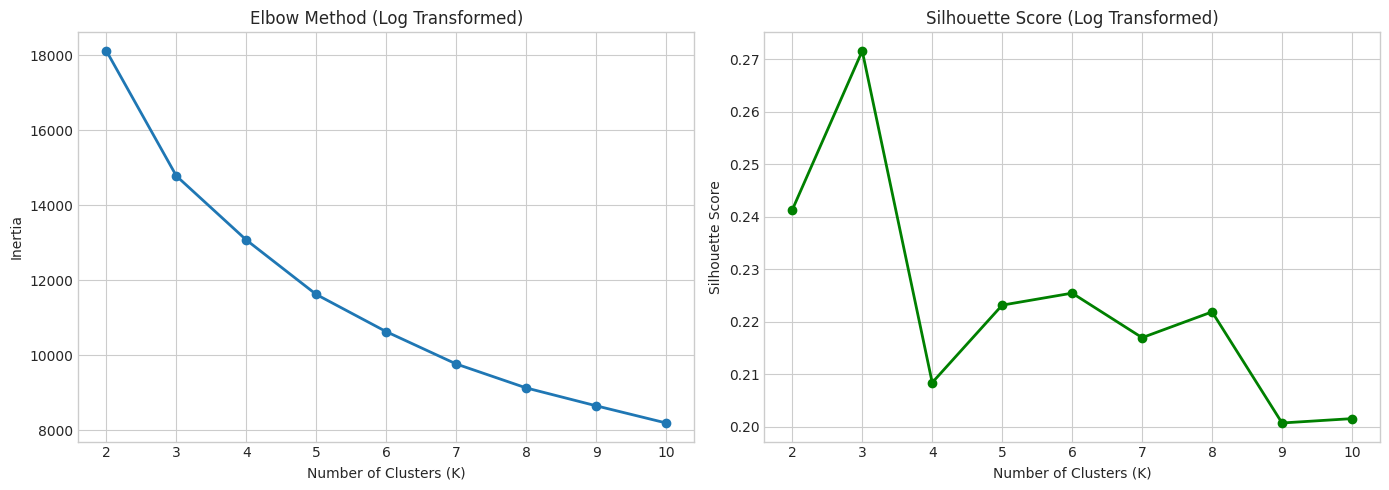

K=2: Silhouette = 0.241
K=3: Silhouette = 0.272
K=4: Silhouette = 0.208
K=5: Silhouette = 0.223
K=6: Silhouette = 0.225
K=7: Silhouette = 0.217
K=8: Silhouette = 0.222
K=9: Silhouette = 0.201
K=10: Silhouette = 0.202


In [14]:
# Determine K again
inertias_log = []
silhouettes_log = []
K_range = range(2, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_log_scaled)
    inertias_log.append(kmeans.inertia_)
    silhouettes_log.append(silhouette_score(X_log_scaled, labels))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(K_range, inertias_log, marker='o', linewidth=2)
axes[0].set_title('Elbow Method (Log Transformed)')
axes[0].set_xlabel('Number of Clusters (K)')
axes[0].set_ylabel('Inertia')

axes[1].plot(K_range, silhouettes_log, marker='o', linewidth=2, color='green')
axes[1].set_title('Silhouette Score (Log Transformed)')
axes[1].set_xlabel('Number of Clusters (K)')
axes[1].set_ylabel('Silhouette Score')

plt.tight_layout()
plt.savefig('/app/outputs/09_optimal_k_with_log.png', dpi=150, bbox_inches='tight')
plt.show()

for k, s in zip(K_range, silhouettes_log):
    print(f"K={k}: Silhouette = {s:.3f}")

**Choosing K - after Log Transformations**  
With log-transformed features, K=3 has the best silhouette score (0.272) and K=4 is probably the best elbow point. 
So, we will profile both to see which produces better, more actionable business segments.

In [15]:
kmeans_log = KMeans(n_clusters=4, random_state=42, n_init=10)
sellers['cluster_log'] = kmeans_log.fit_predict(X_log_scaled)

profile_log = sellers.groupby('cluster_log')[feature_cols].mean()
profile_log['count'] = sellers.groupby('cluster_log').size()
profile_log

,total_orders,total_revenue,avg_price,unique_products,category_concentration,avg_review_score,avg_delivery_days,on_time_rate,count
cluster_log,,,,,,,,,
0,4.10,345.00,70.88,2.74,0.90,4.38,9.77,0.97,1206
1,110.50,15975.20,119.80,33.89,0.83,4.15,12.14,0.92,763
2,2.71,839.71,258.01,1.91,0.92,2.66,30.93,0.29,125
3,9.37,3091.65,363.52,4.86,0.88,4.14,12.74,0.92,876


In [16]:
kmeans_log3 = KMeans(n_clusters=3, random_state=42, n_init=10)
sellers['cluster_log3'] = kmeans_log3.fit_predict(X_log_scaled)

profile_log3 = sellers.groupby('cluster_log3')[feature_cols].mean()
profile_log3['count'] = sellers.groupby('cluster_log3').size()
profile_log3

,total_orders,total_revenue,avg_price,unique_products,category_concentration,avg_review_score,avg_delivery_days,on_time_rate,count
cluster_log3,,,,,,,,,
0,4.31,643.91,157.80,2.78,0.91,4.33,10.37,0.97,1664
1,78.34,12328.23,192.90,24.95,0.83,4.15,12.45,0.92,1151
2,3.00,1013.79,277.27,2.07,0.92,2.76,28.90,0.36,155


**Observations -**  
K=3 has the better silhouette score (0.272 vs 0.208), but K=3's largest cluster contains 1,664 sellers (56%) 
mixing very small low-price sellers with moderate higher-price sellers. K=4 splits this into two distinct groups: **small & reliable** (1,206 sellers, avg price R\\$71) and **mid-tier** (876 sellers, avg price R\\$258), 
which represent fundamentally different business types. The underperformer cluster remains consistent 
across both, validating it as a real segment. We proceed with **K=4**.

#### Finalize Clusters

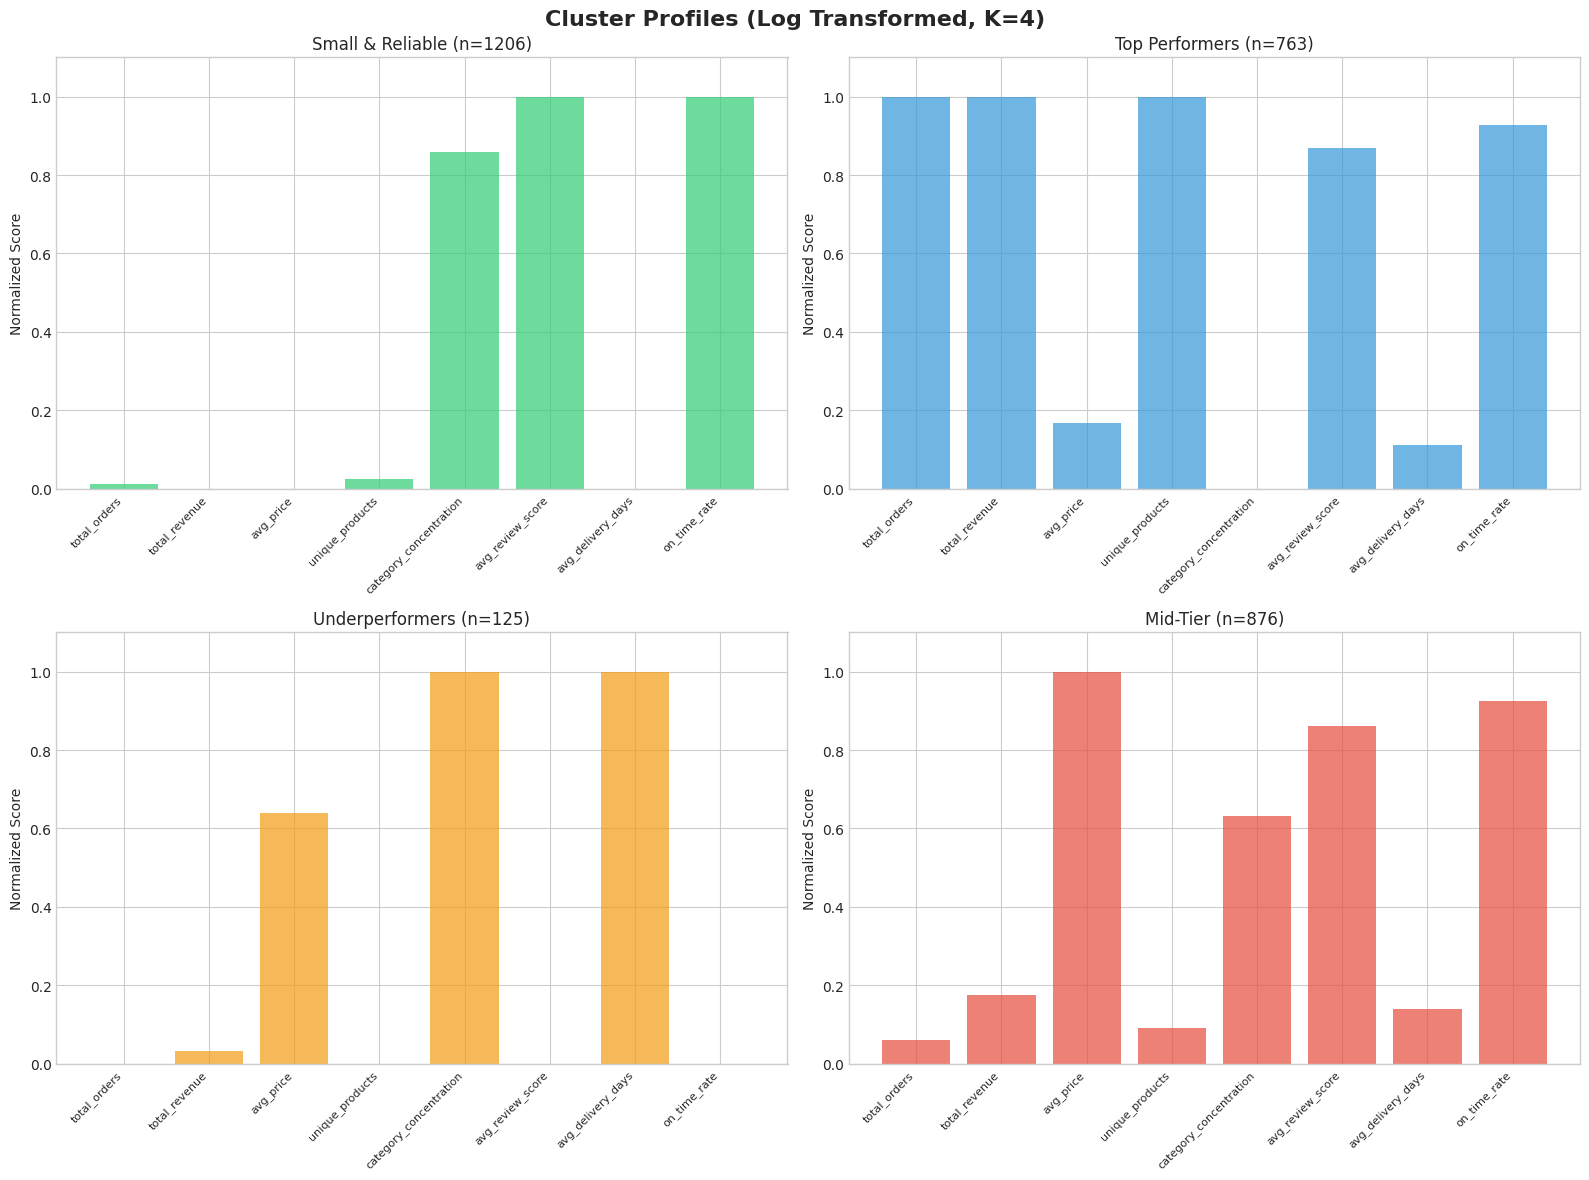

In [17]:
# Normalize features to 0-1 for comparison
from sklearn.preprocessing import MinMaxScaler

profile_data = sellers.groupby('cluster_log')[feature_cols].mean()
minmax = MinMaxScaler()
profile_normalized = pd.DataFrame(
    minmax.fit_transform(profile_data),
    columns=feature_cols,
    index=profile_data.index
)

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Cluster Profiles (Log Transformed, K=4)', fontsize=16, fontweight='bold')

cluster_names = {
    0: 'Small & Reliable',
    1: 'Top Performers',
    2: 'Underperformers',
    3: 'Mid-Tier'
}
colors = ['#2ecc71', '#3498db', '#f39c12', '#e74c3c']

for idx, (cluster, row) in enumerate(profile_normalized.iterrows()):
    ax = axes[idx // 2, idx % 2]
    ax.bar(range(len(feature_cols)), row.values, color=colors[idx], alpha=0.7)
    ax.set_xticks(range(len(feature_cols)))
    ax.set_xticklabels(feature_cols, rotation=45, ha='right', fontsize=8)
    ax.set_ylim(0, 1.1)
    count = int(profile_log.loc[cluster, 'count'])
    ax.set_title(f'{cluster_names[cluster]} (n={count})')
    ax.set_ylabel('Normalized Score')

plt.tight_layout()
plt.savefig('/app/outputs/10_cluster_profiles_log.png', dpi=150, bbox_inches='tight')
plt.show()

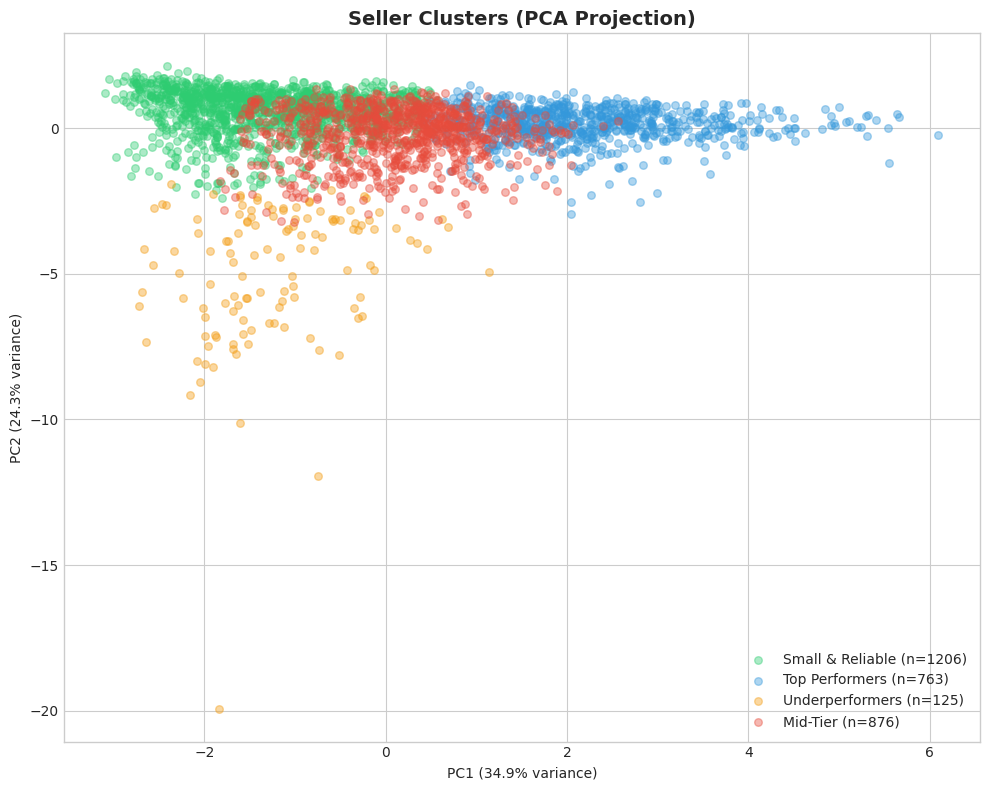

In [18]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_log_scaled)

fig, ax = plt.subplots(figsize=(10, 8))

for cluster in sorted(sellers['cluster_log'].unique()):
    mask = sellers['cluster_log'] == cluster
    ax.scatter(X_pca[mask, 0], X_pca[mask, 1], 
              label=f'{cluster_names[cluster]} (n={mask.sum()})',
              alpha=0.4, s=30, color=colors[cluster])

ax.set_title('Seller Clusters (PCA Projection)', fontsize=14, fontweight='bold')
ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%} variance)')
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%} variance)')
ax.legend()

plt.tight_layout()
plt.savefig('/app/outputs/11_pca_clusters.png', dpi=150, bbox_inches='tight')
plt.show()

In [19]:
pca_loadings = pd.DataFrame(
    pca.components_.T,
    columns=['PC1', 'PC2'],
    index=feature_cols
)
print(pca_loadings.round(3))

                         PC1   PC2
total_orders            0.57  0.05
total_revenue           0.57 -0.03
avg_price               0.13 -0.15
unique_products         0.56  0.05
category_concentration -0.14 -0.03
avg_review_score       -0.02  0.52
avg_delivery_days       0.02 -0.59
on_time_rate            0.00  0.59


### Final Cluster Analysis

#### Cluster Profiles
- **Small & Reliable (n=1206, 41%):** Low average order volume and revenue, but highest review scores (4.38) and on-time rates (97%). Highly specialized sellers, likely newer or niche. Fast delivery (9.8 days avg).
- **Top Performers (n=763, 26%):** Highest order volume (110 average), revenue (R\\$16K), and product diversity (34 products). Maintain strong quality (4.15 average review score, 92% on-time) despite scale.
- **Underperformers (n=125, 4%):** Average prices are on the higher end (R\\$258) but worst quality metrics: 2.66 review score, 31-day average delivery time, and 29% on-time rate. Highly specialized but failing on execution.
- **Mid-Tier (n=876, 29%):** Moderate volume (~9 orders, R\\$3K revenue), highest average price among healthy sellers. Good review scores (4.14) and on-time rate (92%). Potential to grow into Top Performers.

#### PCA Visualization
PC1 (34.9% variance) primarily captures seller scale — Top Performers are on the far right, Small & Reliable on the left. PC2 (24.3% variance) captures quality and delivery — Underperformers drop sharply downward, separating clearly from the rest. Together, the two components explain 59.2% of variance. Small & Reliable and Mid-Tier overlap in the center-left, reflecting similar volume but differing on price and product diversity.

### Further Analysis

In [20]:
# Dominant category 
cluster_cats = sellers.groupby(['cluster_log', 'dominant_category']).size().reset_index(name='count')
cluster_cats['pct'] = cluster_cats.groupby('cluster_log')['count'].transform(lambda x: x / x.sum() * 100)

for cluster in sorted(sellers['cluster_log'].unique()):
    print(f"\n{'='*50}")
    print(f"Cluster {cluster}: {cluster_names[cluster]}")
    print(f"{'='*50}")
    top_cats = cluster_cats[cluster_cats['cluster_log'] == cluster].sort_values('pct', ascending=False).head(5)
    for _, row in top_cats.iterrows():
        print(f"  {row['dominant_category']}: {row['pct']:.1f}% ({int(row['count'])} sellers)")


Cluster 0: Small & Reliable
  Home & Living: 24.6% (297 sellers)
  Health, Beauty & Personal Care: 18.4% (222 sellers)
  Sports, Leisure & Toys: 15.1% (182 sellers)
  Auto & Industrial: 10.1% (122 sellers)
  Electronics & Tech: 7.8% (94 sellers)

Cluster 1: Top Performers
  Home & Living: 30.7% (234 sellers)
  Sports, Leisure & Toys: 16.4% (125 sellers)
  Health, Beauty & Personal Care: 16.3% (124 sellers)
  Electronics & Tech: 13.2% (101 sellers)
  Fashion & Accessories: 7.1% (54 sellers)

Cluster 2: Underperformers
  Home & Living: 28.0% (35 sellers)
  Health, Beauty & Personal Care: 14.4% (18 sellers)
  Electronics & Tech: 13.6% (17 sellers)
  Auto & Industrial: 9.6% (12 sellers)
  Sports, Leisure & Toys: 8.8% (11 sellers)

Cluster 3: Mid-Tier
  Home & Living: 25.5% (223 sellers)
  Sports, Leisure & Toys: 17.1% (150 sellers)
  Health, Beauty & Personal Care: 13.6% (119 sellers)
  Auto & Industrial: 12.8% (112 sellers)
  Other / Misc: 9.7% (85 sellers)


In [21]:
# Revenue 
cluster_revenue = sellers.groupby('cluster_log').agg(
    total_rev=('total_revenue', 'sum'),
    seller_count=('seller_id', 'count')
).reset_index()
cluster_revenue['rev_pct'] = (cluster_revenue['total_rev'] / cluster_revenue['total_rev'].sum() * 100).round(1)
cluster_revenue['seller_pct'] = (cluster_revenue['seller_count'] / cluster_revenue['seller_count'].sum() * 100).round(1)
cluster_revenue['cluster_name'] = cluster_revenue['cluster_log'].map(cluster_names)

print("Revenue Contribution by Cluster:")
print(f"{'='*60}")
for _, row in cluster_revenue.iterrows():
    print(f"  {row['cluster_name']}: {row['rev_pct']}% of revenue, {row['seller_pct']}% of sellers")

Revenue Contribution by Cluster:
  Small & Reliable: 2.7% of revenue, 40.6% of sellers
  Top Performers: 79.1% of revenue, 25.7% of sellers
  Underperformers: 0.7% of revenue, 4.2% of sellers
  Mid-Tier: 17.6% of revenue, 29.5% of sellers


In [22]:
# Geography
cluster_geo = sellers.groupby(['cluster_log', 'seller_region']).size().reset_index(name='count')
cluster_geo['pct'] = cluster_geo.groupby('cluster_log')['count'].transform(lambda x: x / x.sum() * 100)

for cluster in sorted(sellers['cluster_log'].unique()):
    print(f"\n{cluster_names[cluster]}:")
    region_data = cluster_geo[cluster_geo['cluster_log'] == cluster].sort_values('pct', ascending=False)
    for _, row in region_data.iterrows():
        print(f"  {row['seller_region']}: {row['pct']:.1f}%")


Small & Reliable:
  Southeast: 71.4%
  South: 24.4%
  Central-West: 2.5%
  Northeast: 1.7%

Top Performers:
  Southeast: 81.2%
  South: 15.9%
  Central-West: 2.1%
  Northeast: 0.8%

Underperformers:
  Southeast: 79.0%
  South: 15.3%
  Central-West: 2.4%
  Northeast: 2.4%
  North: 0.8%

Mid-Tier:
  Southeast: 67.6%
  South: 26.1%
  Central-West: 3.2%
  Northeast: 2.9%
  North: 0.2%


Mid-Tier vs Top Performers Gap Analysis:
                        Mid-Tier Avg  Top Performer Avg  Gap (%)
total_orders                    9.37             110.50    91.50
total_revenue                3091.65           15975.20    80.60
avg_price                     363.52             119.80  -203.40
unique_products                 4.86              33.89    85.70
category_concentration          0.88               0.83    -6.90
avg_review_score                4.14               4.15     0.30
avg_delivery_days              12.74              12.14    -4.90
on_time_rate                    0.92               0.92     0.30


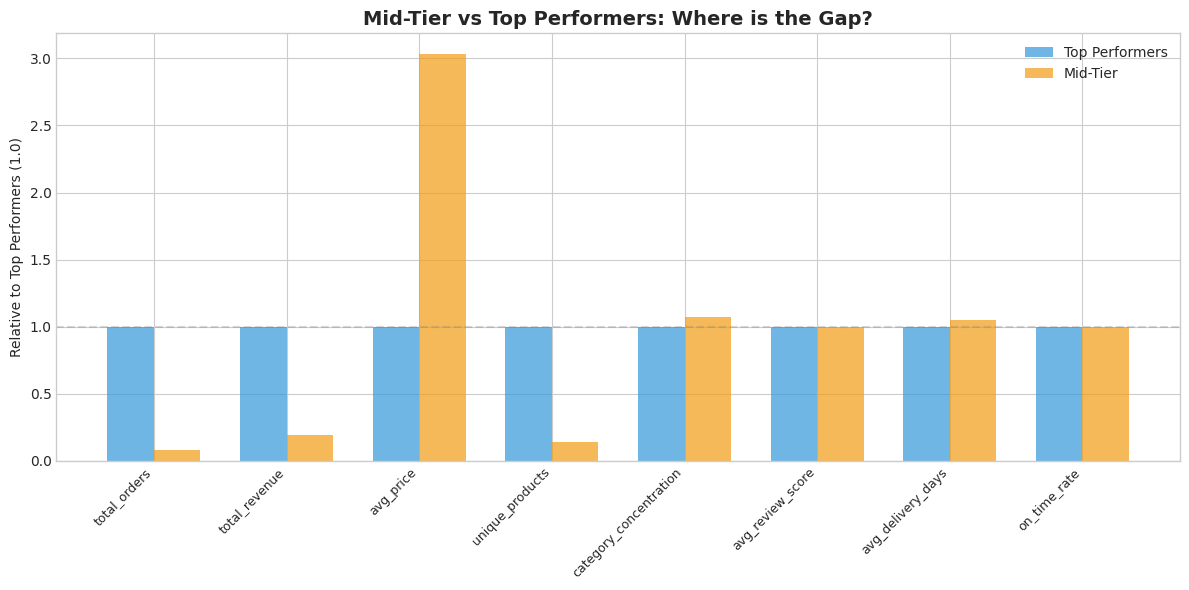

In [23]:
# Mid-Tier vs Top Performers 
midtier_avg = sellers[sellers['cluster_log'] == 3][feature_cols].mean()
top_avg = sellers[sellers['cluster_log'] == 1][feature_cols].mean()

gap = pd.DataFrame({
    'Mid-Tier Avg': midtier_avg,
    'Top Performer Avg': top_avg,
    'Gap (%)': ((top_avg - midtier_avg) / top_avg * 100).round(1)
})
print("Mid-Tier vs Top Performers Gap Analysis:")
print(gap.to_string())

fig, ax = plt.subplots(figsize=(12, 6))

x = range(len(feature_cols))
width = 0.35

# Normalize both to Top Performer = 1.0 for comparison
midtier_normalized = (midtier_avg / top_avg).values
top_normalized = [1.0] * len(feature_cols)

bars1 = ax.bar([i - width/2 for i in x], top_normalized, width, label='Top Performers', color='#3498db', alpha=0.7)
bars2 = ax.bar([i + width/2 for i in x], midtier_normalized, width, label='Mid-Tier', color='#f39c12', alpha=0.7)

ax.set_xticks(x)
ax.set_xticklabels(feature_cols, rotation=45, ha='right', fontsize=9)
ax.set_ylabel('Relative to Top Performers (1.0)')
ax.set_title('Mid-Tier vs Top Performers: Where is the Gap?', fontsize=14, fontweight='bold')
ax.legend()
ax.axhline(y=1.0, color='gray', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.savefig('/app/outputs/12_cluster_gap_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

### Key Findings

**Revenue Concentration:** Top Performers (26% of sellers) generate 79% of platform revenue. 
Small & Reliable sellers (41% of sellers) contribute only 2.7%. 
The platform is heavily dependent on a small group of high-performing sellers.

**Category Distribution:** Similar across all clusters, dominated by Home & Living. 
Cluster differences are driven by operational performance, not product specialization.

**Geography:** Southeast dominates all clusters (67-81%). 
Underperformer issues are operational (slow delivery, poor quality), not location-based.

#### Cluster Transition: Mid-Tier → Top Performers

Mid-Tier sellers already match Top Performers on quality: 
* Average Review Scores (4.14 vs 4.15), 
* Delivery days (12.7 vs 12.1), and on-time rate (both 92%).
* The gap is entirely in scale: Orders (91.5% gap), Revenue (80.6%), and Product Diversity (85.7%).


Mid-Tier sellers average 3x higher prices (R\\$364 vs R\\$120) and sell far fewer products (5 vs 34). 
They run smaller, higher-value operations. Growing into Top Performers would require 
expanding product catalogs and driving order volume, not improving quality.

This makes them strong candidates for growth programs: the hardest part (delivery and customer satisfaction) 
is already solved. The focus should be on visibility, marketing support, and catalog expansion.

---

### Business Recommendations by Segment

1. **Small & Reliable** (1,206 sellers | 41% of sellers | 2.7% of revenue)
   - Massive untapped potential: if even 10% grow to Mid-Tier, that adds significant revenue
   - Action: Seller growth programs, featured placement, category expansion nudges
   - Risk: Low engagement, may become inactive without nurturing


2. **Top Performers** (763 sellers | 26% of sellers | 79% of revenue)
   - Platform backbone: losing even a few would significantly impact revenue
   - Action: Priority support, loyalty incentives, retention programs
   - Risk: High platform dependence on this segment


3. **Underperformers** (125 sellers | 4% of sellers | 0.7% of revenue)
   - Negligible revenue contribution but damaging customer trust
   - Action: Delivery audits, logistics support, potential delisting if no improvement
   - Risk: Disproportionate negative impact on customer experience

4. **Mid-Tier** (876 sellers | 29% of sellers | 17.6% of revenue)
   - Strongest growth candidates: already match Top Performers on quality (4.14 vs 4.15 reviews, 92% on-time)
   - Gap is purely volume and catalog size, not quality
   - Action: Marketing support, catalog expansion incentives, visibility boosts
   - Risk: May stagnate without active growth programs

#### Save the Results

In [24]:
# Save seller clusters to duckdb
con.execute("CREATE SCHEMA IF NOT EXISTS ml_outputs")
con.execute("DROP TABLE IF EXISTS ml_outputs.seller_clusters")

cluster_output = sellers[['seller_id', 'cluster_log']].rename(
    columns={'cluster_log': 'cluster'}
).assign(cluster_name=lambda x: x['cluster'].map(cluster_names))

con.execute("CREATE TABLE ml_outputs.seller_clusters AS SELECT * FROM cluster_output")
print(f"Saved {len(cluster_output)} sellers to ml_outputs.seller_clusters")
con.close()

Saved 2970 sellers to ml_outputs.seller_clusters
